In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from notebooks.models.utility import load_and_validate_final_data

final_data, features = load_and_validate_final_data(version='oligo')

In [4]:
from notebooks.consts import NOTEBOOK_PATH

SEEN_MODELS_FOLDER = NOTEBOOK_PATH / 'models' / 'SeenOligoModel'

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Configuration
MODEL_PATH = SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"
HISTORY_PATH = SEEN_MODELS_FOLDER / "Model_Oligo_L2_RFE_History.csv"
TOP_N_FEATURES = 20

In [6]:
print("Loading final model...")
bst = xgb.Booster()
bst.load_model(MODEL_PATH)

# Extract importance scores (Gain = average reduction in training loss)
importance_dict = bst.get_score(importance_type='gain')

# Convert to a sorted Pandas DataFrame
df_importance = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Gain']
).sort_values(by='Gain', ascending=False).reset_index(drop=True)

# Calculate relative importance (percentage)
df_importance['Relative_Gain (%)'] = (df_importance['Gain'] / df_importance['Gain'].sum()) * 100

print(f"Model uses {len(df_importance)} features.")
display(df_importance.head(10))

Loading final model...
Model uses 41 features.


,Feature,Gain,Relative_Gain (%)
0,Sequence_gc_content,46758.222656,5.802917
1,sense_intron,46118.300781,5.723499
2,ps_end_score,42944.039062,5.329558
3,Sequence_a_count,38641.515625,4.795595
4,Other,36026.570312,4.471068
5,target_expression,26947.886719,3.344360
6,Gymnosis,26025.126953,3.229841
7,OHE_pos0_G,25912.599609,3.215876
8,Sequence_entropy,25385.523438,3.150464
9,cells_per_well,22589.386719,2.803450


In [14]:
df_importance

,Feature,Gain,Relative_Gain (%)
0,Sequence_gc_content,46758.222656,5.802917
1,sense_intron,46118.300781,5.723499
2,ps_end_score,42944.039062,5.329558
3,Sequence_a_count,38641.515625,4.795595
4,Other,36026.570312,4.471068
5,target_expression,26947.886719,3.344360
6,Gymnosis,26025.126953,3.229841
7,OHE_pos0_G,25912.599609,3.215876
8,Sequence_entropy,25385.523438,3.150464
9,cells_per_well,22589.386719,2.803450


/tmp/ipykernel_1686940/2729547288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Relative_Gain (%)', y='Feature', palette='viridis')


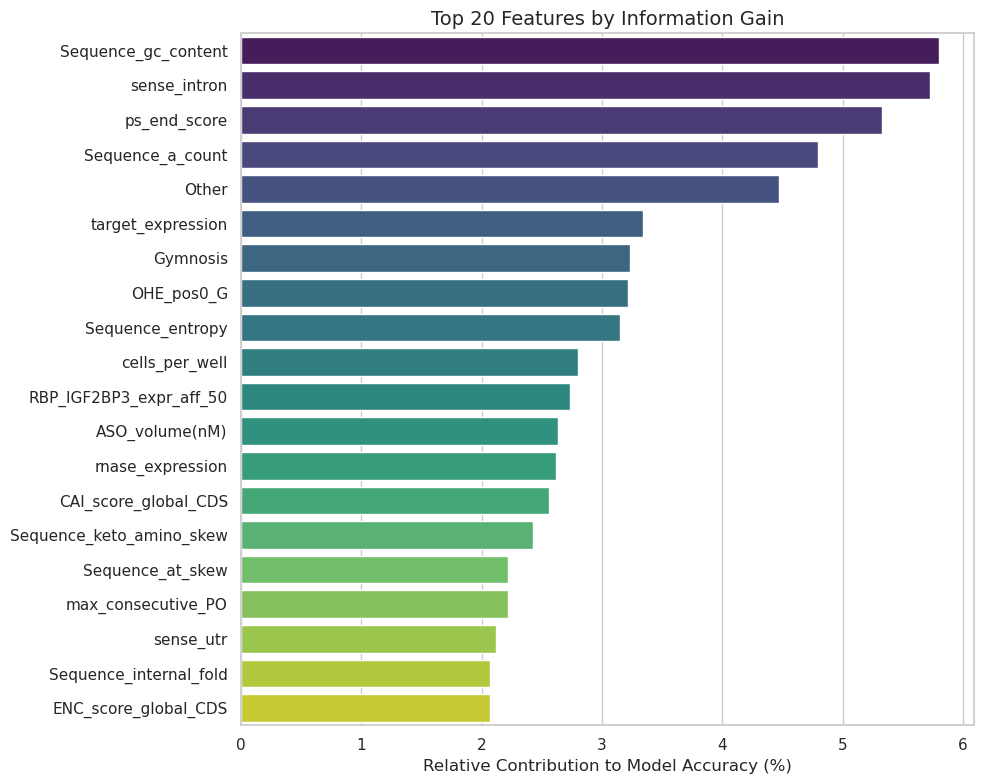

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Plot the Top N features
top_features = df_importance.head(TOP_N_FEATURES)
sns.barplot(data=top_features, x='Relative_Gain (%)', y='Feature', palette='viridis')

plt.title(f"Top {TOP_N_FEATURES} Features by Information Gain", fontsize=14)
plt.xlabel("Relative Contribution to Model Accuracy (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Comparing Top 10% (n=13657) vs Bottom 30% (n=39316) cohorts...


/tmp/ipykernel_1686940/1512652308.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1686940/1512652308.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1686940/1512652308.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1686940/1512652308.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1686940/1512652308.py:47: Fut

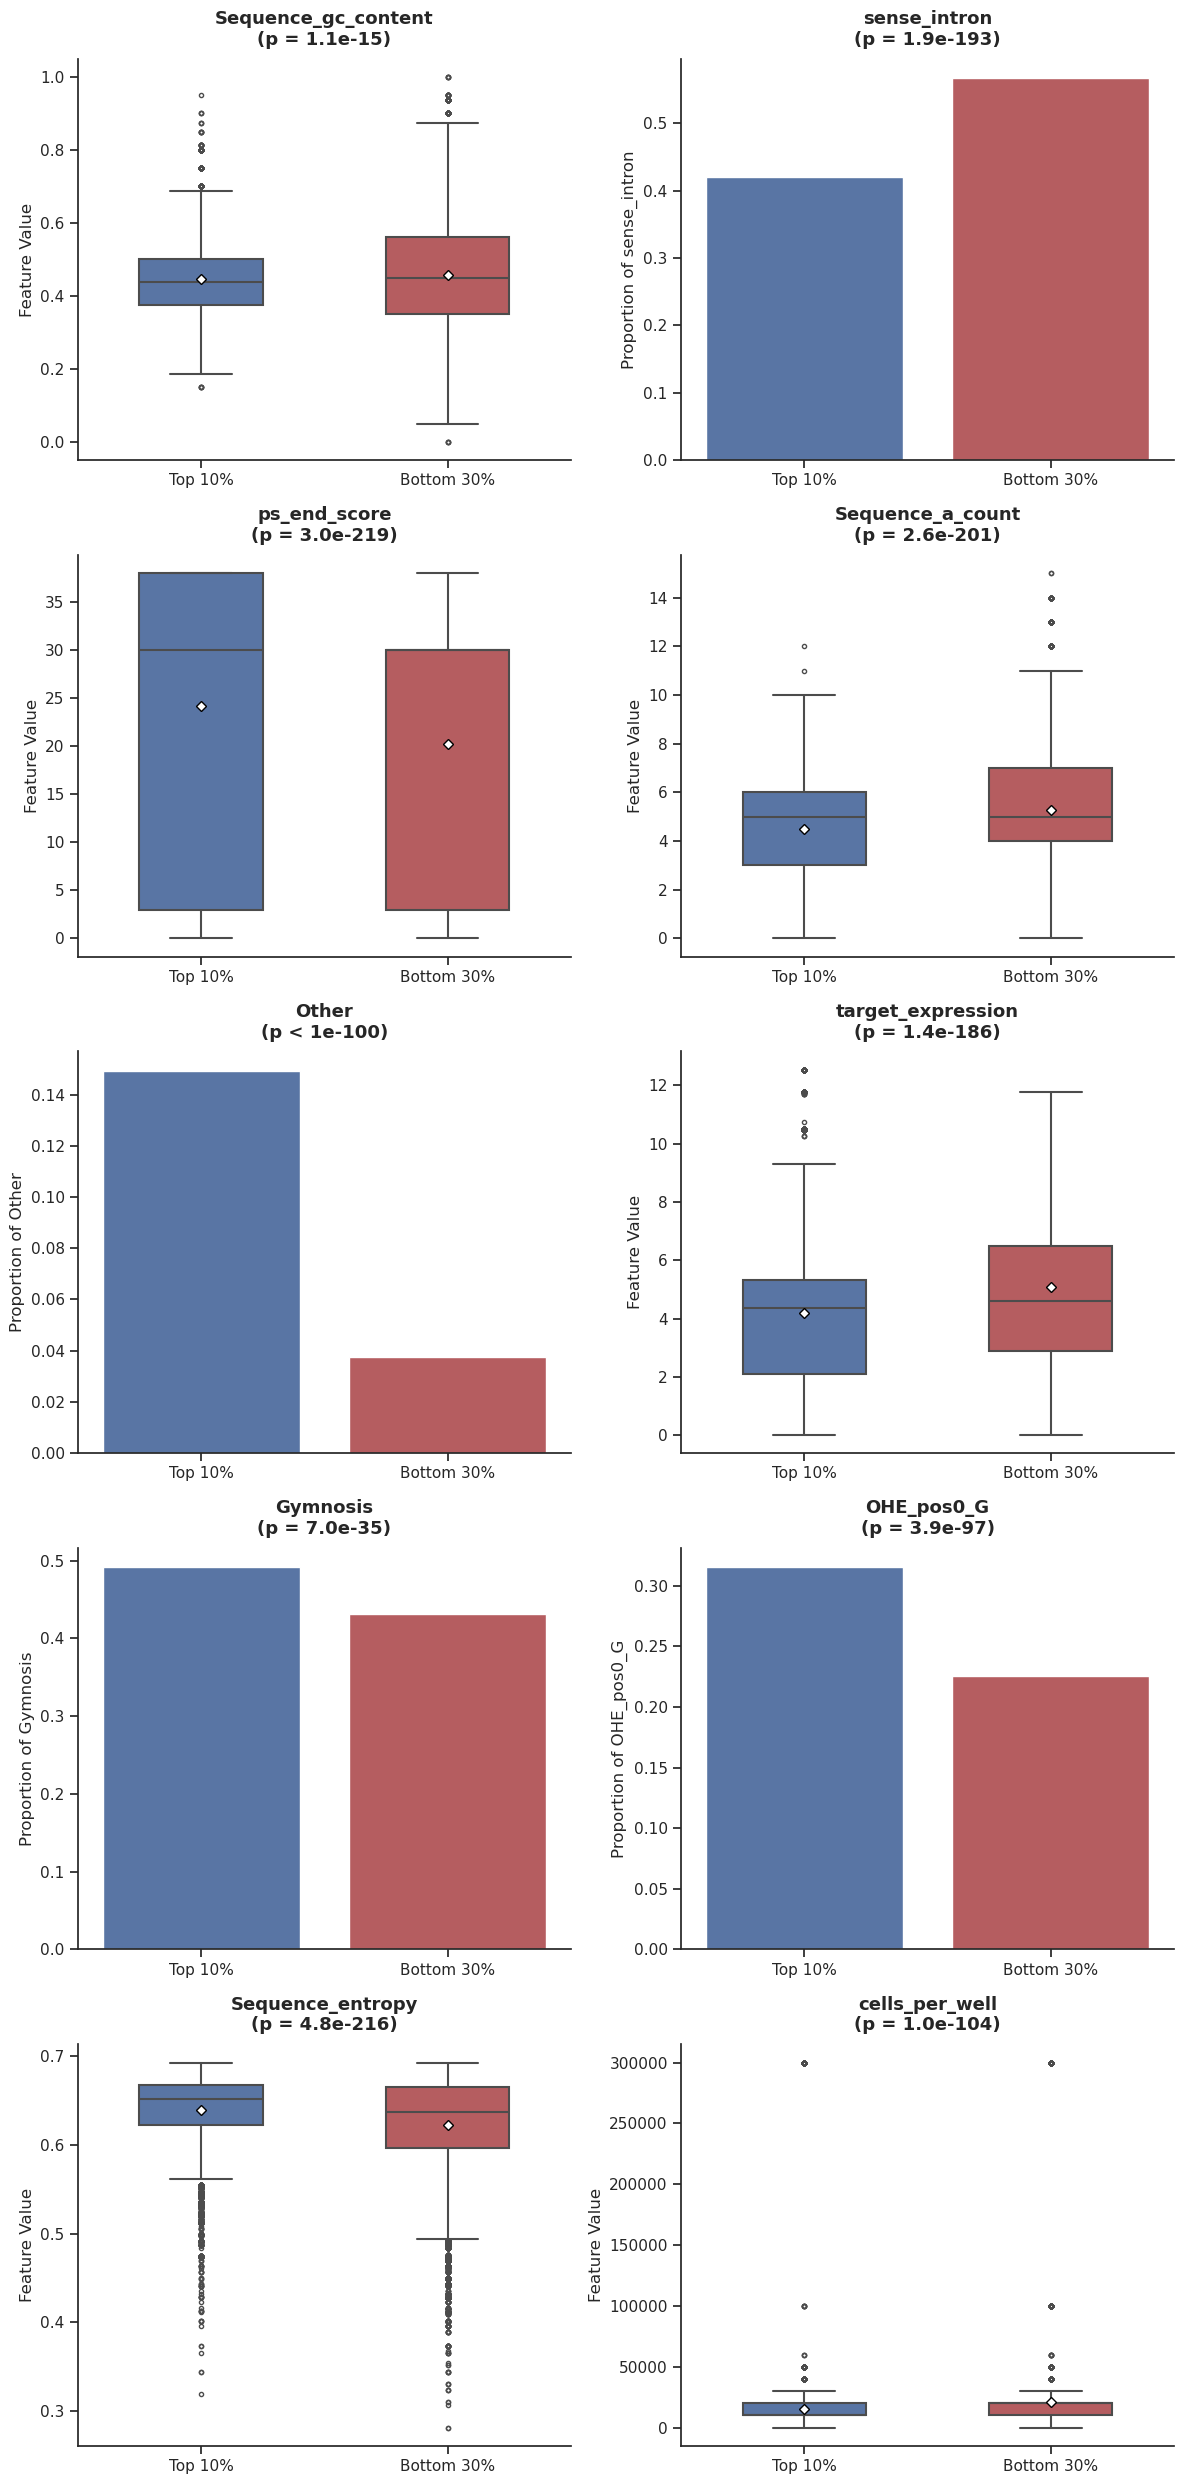

<Figure size 640x480 with 0 Axes>

Analyzing RFE Selection History...


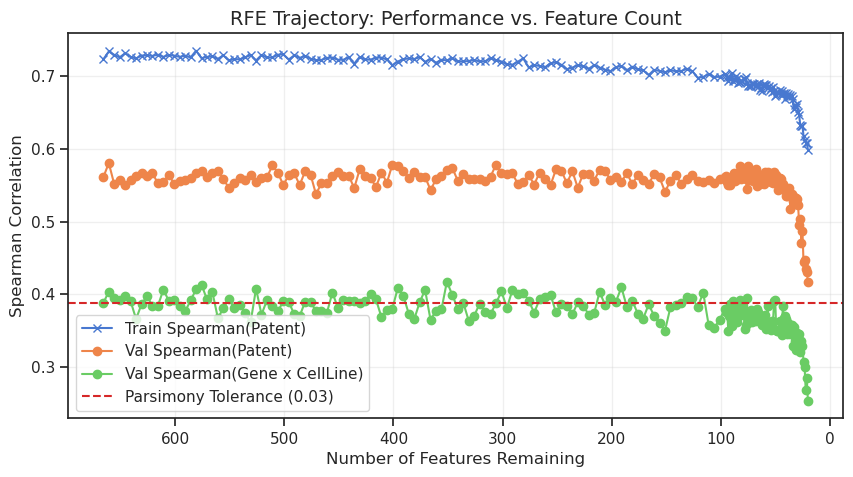

In [23]:
from scipy.stats import mannwhitneyu
from tauso.data.consts import INHIBITION


from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_feature_distributions(df, features_to_analyze, top_pct=0.10, bottom_pct=0.30):
    # 1. Split into cohorts
    top_thresh = df[INHIBITION].quantile(1 - top_pct)
    bottom_thresh = df[INHIBITION].quantile(bottom_pct)

    df_top = df[df[INHIBITION] >= top_thresh].copy()
    df_top['Cohort'] = f'Top {int(top_pct * 100)}%'

    df_bottom = df[df[INHIBITION] <= bottom_thresh].copy()
    df_bottom['Cohort'] = f'Bottom {int(bottom_pct * 100)}%'

    df_plot = pd.concat([df_top, df_bottom])

    # 2. Setup Plotting (Clean, publication-ready style)
    sns.set_theme(style="ticks", palette="muted") # "ticks" is cleaner than "whitegrid"
    n_feats = len(features_to_analyze)
    cols = 2
    rows = int(np.ceil(n_feats / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten()

    print(f"Comparing Top {int(top_pct*100)}% (n={len(df_top)}) vs Bottom {int(bottom_pct*100)}% (n={len(df_bottom)}) cohorts...")

    for i, feat in enumerate(features_to_analyze):
        ax = axes[i]

        # Clean data for stats testing (drop NaNs to avoid p=nan)
        valid_top = df_top[feat].dropna()
        valid_bot = df_bottom[feat].dropna()

        # Check if the feature is binary (only contains 0, 1, or NaN)
        is_binary = set(df_plot[feat].dropna().unique()).issubset({0, 1, 0.0, 1.0})

        if is_binary:
            # Plot Binary Features as Proportions (Bar Chart)
            sns.barplot(
                data=df_plot, x='Cohort', y=feat, ax=ax,
                palette=["#4C72B0", "#C44E52"], # Professional Blue/Red combo
                errorbar=None
            )
            ax.set_ylabel(f"Proportion of {feat}")
        else:
            # Plot Continuous Features as Boxplots with a refined look
            sns.boxplot(
                data=df_plot, x='Cohort', y=feat, ax=ax,
                palette=["#4C72B0", "#C44E52"], width=0.5,
                linewidth=1.5, fliersize=3,
                showmeans=True, meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5}
            )
            ax.set_ylabel("Feature Value")

        # 3. Statistical Significance (Mann-Whitney U test)
        if len(valid_top) > 0 and len(valid_bot) > 0:
            stat, p_val = mannwhitneyu(valid_top, valid_bot, alternative='two-sided')

            # Format P-value cleanly
            if pd.isna(p_val):
                p_text = "p = NaN (Check data variance)"
            elif p_val == 0.0:
                p_text = "p < 1e-100"
            elif p_val < 0.001:
                p_text = f"p = {p_val:.1e}"
            else:
                p_text = f"p = {p_val:.3f}"
        else:
            p_text = "p = NaN (Missing Data)"

        ax.set_title(f"{feat}\n({p_text})", fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("")

        # Remove top and right borders for a cleaner look
        sns.despine(ax=ax)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    plt.tight_layout()
    plt.show()


# Run the analysis on the Top 10 features identified by your XGBoost model
top_10_model_features = df_importance.head(10)['Feature'].tolist()
analyze_feature_distributions(final_data, top_10_model_features)

# Analyze the RFE History to see the pruning trajectory
print("Analyzing RFE Selection History...")
df_history = pd.read_csv(HISTORY_PATH)

# Convert string representation of list back to actual list
df_history['dropped_features'] = df_history['dropped_features'].apply(ast.literal_eval)

# Plot selection metrics over time
plt.figure(figsize=(10, 5))
plt.plot(df_history['num_features'], df_history['train_spearman'], label='Train Spearman(Patent)', marker='x')
plt.plot(df_history['num_features'], df_history['val_spearman'], label='Val Spearman(Patent)', marker='o')
plt.plot(df_history['num_features'], df_history['val_spearman_select'], label='Val Spearman(Gene x CellLine)', marker='o')

# Calculate threshold correctly
peak_val = df_history['val_spearman_select'].max()
plt.axhline(y=peak_val - 0.03, color='#d62728', linestyle='--', label='Parsimony Tolerance (0.03)')

plt.gca().invert_xaxis()  # RFE goes from high features to low
plt.title("RFE Trajectory: Performance vs. Feature Count", fontsize=14)
plt.xlabel("Number of Features Remaining")
plt.ylabel("Spearman Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()